# IDC Evaluation and Model Comparison

This notebook evaluates one saved run in detail and also compares multiple saved runs.

Why these plots matter:
- the dataset is imbalanced, so precision, recall, F1, and the precision-recall curve are especially important
- the ROC curve is still useful as a threshold-independent ranking view
- thresholds are selected on the validation split only, then applied once to test


In [43]:
from google.colab import drive
from pathlib import Path
import sys

drive.mount('/content/drive')

# Notebook 06 evaluates one saved run in detail and optionally compares multiple saved runs.
PROJECT_ROOT = Path('/content/drive/MyDrive/Workshop UDL')
SRC_DIR = PROJECT_ROOT / 'src'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
DATASET_ARCHIVE_PATH = PROJECT_ROOT / 'datasets' / 'Breast Cancer Histopathology Dataset.zip'
TRAINING_RUNS_DIR = PROJECT_ROOT / 'training_runs'
COMPARISON_DIR = PROJECT_ROOT / 'model_comparison'

RUNTIME_DIR = Path('/content/idc_runtime')
RUNTIME_EXTRACT_DIR = RUNTIME_DIR / 'dataset'

RUN_NAME = 'baseline_cnn_improved_seed42'

MODEL_LABELS = {
    'baseline_cnn_seed42': 'Baseline CNN',
    'baseline_cnn_improved_seed42': 'Improved Baseline CNN',
    'resnet18_transfer_seed42': 'Pretrained ResNet18',
}

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

if not SRC_DIR.exists():
    raise FileNotFoundError(
        f'Source directory not found: {SRC_DIR}. '
        'Put the project folder in Google Drive so Colab can import src/idc_pipeline.'
    )

COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Artifacts dir: {ARTIFACTS_DIR}')
print(f'Dataset archive cache: {DATASET_ARCHIVE_PATH}')
print(f'Comparison dir: {COMPARISON_DIR}')
print(f'Active run name: {RUN_NAME}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/Workshop UDL
Artifacts dir: /content/drive/MyDrive/Workshop UDL/artifacts
Dataset archive cache: /content/drive/MyDrive/Workshop UDL/datasets/Breast Cancer Histopathology Dataset.zip
Comparison dir: /content/drive/MyDrive/Workshop UDL/model_comparison
Active run name: baseline_cnn_improved_seed42


In [44]:
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image
from torch.utils.data import DataLoader

from idc_pipeline.dataset import DatasetNormalization, IDCPatchDataset
from idc_pipeline.download import prepare_dataset_from_cached_zip
from idc_pipeline.evaluate import (
    compute_average_precision,
    compute_binary_metrics,
    compute_binary_precision_recall_curve,
    compute_binary_roc_curve,
    confusion_matrix_from_metrics,
    predict_model_outputs,
    select_best_threshold,
    sweep_thresholds,
)
from idc_pipeline.train import load_checkpoint_model


def load_json(path: Path) -> dict:
    return json.loads(path.read_text())


def resolve_run_dir(run_name: str) -> Path:
    # Support both the standard training_runs layout and the older nested backup layout.
    candidate_roots = [
        TRAINING_RUNS_DIR / run_name,
        PROJECT_ROOT / run_name,
    ]

    for candidate_root in candidate_roots:
        for candidate in (candidate_root, candidate_root / run_name):
            if (candidate / 'best_model.pt').exists() and (candidate / 'metrics.json').exists():
                return candidate

    checked_paths = []
    for candidate_root in candidate_roots:
        checked_paths.append(str(candidate_root))
        checked_paths.append(str(candidate_root / run_name))
    checked_text = '\n'.join(checked_paths)
    raise FileNotFoundError(f'Could not resolve run directory for {run_name}. Checked:\n{checked_text}')


def get_model_display_name(run_name: str, architecture: str) -> str:
    label = MODEL_LABELS.get(run_name)
    if label is not None:
        return label

    if run_name.startswith('baseline_cnn_improved_'):
        return 'Improved Baseline CNN'
    if run_name.startswith('baseline_cnn_'):
        return 'Baseline CNN'
    if run_name.startswith('resnet18_transfer_'):
        return 'Pretrained ResNet18'

    return architecture.replace('_', ' ').title()


def build_normalization(training_config: dict) -> DatasetNormalization | None:
    mean = training_config.get('normalization_mean')
    std = training_config.get('normalization_std')
    if mean is None or std is None:
        return None
    return DatasetNormalization(mean=tuple(mean), std=tuple(std))


def build_image_size(training_config: dict) -> tuple[int, int] | None:
    image_size = training_config.get('image_size')
    if image_size is None:
        return None
    return tuple(int(value) for value in image_size)


def build_dataloader(split_csv_path: Path, dataset_dir: Path, training_config: dict, batch_size: int, num_workers: int):
    normalization = build_normalization(training_config)
    image_size = build_image_size(training_config)
    dataset = IDCPatchDataset(
        split_csv_path,
        dataset_dir,
        augment=False,
        normalization=normalization,
        image_size=image_size,
    )
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available(),
    )
    return dataset, loader


def make_threshold_comparison_df(default_metrics, tuned_metrics, default_threshold, best_threshold, metric_name):
    return pd.DataFrame(
        [
            {'setting': 'default_0.50', 'threshold': default_threshold, **default_metrics.to_dict()},
            {'setting': f'tuned_{metric_name}', 'threshold': best_threshold, **tuned_metrics.to_dict()},
        ]
    )


def evaluate_saved_run(
    run_name: str,
    *,
    dataset_dir: Path,
    val_csv_path: Path,
    test_csv_path: Path,
    device: torch.device,
    evaluation_batch_size: int,
    evaluation_num_workers: int,
    thresholds: list[float],
    threshold_metric: str,
) -> dict:
    run_dir = resolve_run_dir(run_name)
    run_config = load_json(run_dir / 'config.json')
    training_config = run_config.get('training_config', {})
    architecture = training_config.get('architecture', 'baseline_cnn')

    model, checkpoint, resolved_device = load_checkpoint_model(run_dir / 'best_model.pt', device=device)

    val_dataset, val_loader = build_dataloader(
        val_csv_path,
        dataset_dir,
        training_config,
        evaluation_batch_size,
        evaluation_num_workers,
    )
    test_dataset, test_loader = build_dataloader(
        test_csv_path,
        dataset_dir,
        training_config,
        evaluation_batch_size,
        evaluation_num_workers,
    )

    val_outputs = predict_model_outputs(model, val_loader, device=resolved_device)
    test_outputs = predict_model_outputs(model, test_loader, device=resolved_device)

    threshold_sweep_df = pd.DataFrame(sweep_thresholds(
        val_outputs.labels,
        val_outputs.probabilities,
        thresholds,
    ))
    best_threshold_row = select_best_threshold(
        val_outputs.labels,
        val_outputs.probabilities,
        thresholds,
        metric_name=threshold_metric,
    )

    default_threshold = 0.5
    best_threshold = float(best_threshold_row['threshold'])

    val_default_metrics = compute_binary_metrics(
        val_outputs.labels,
        val_outputs.probabilities,
        threshold=default_threshold,
    )
    val_best_metrics = compute_binary_metrics(
        val_outputs.labels,
        val_outputs.probabilities,
        threshold=best_threshold,
    )
    test_default_metrics = compute_binary_metrics(
        test_outputs.labels,
        test_outputs.probabilities,
        threshold=default_threshold,
    )
    test_best_metrics = compute_binary_metrics(
        test_outputs.labels,
        test_outputs.probabilities,
        threshold=best_threshold,
    )

    val_roc_curve_df = pd.DataFrame(compute_binary_roc_curve(val_outputs.labels, val_outputs.probabilities))
    test_roc_curve_df = pd.DataFrame(compute_binary_roc_curve(test_outputs.labels, test_outputs.probabilities))
    val_pr_curve_df = pd.DataFrame(compute_binary_precision_recall_curve(val_outputs.labels, val_outputs.probabilities))
    test_pr_curve_df = pd.DataFrame(compute_binary_precision_recall_curve(test_outputs.labels, test_outputs.probabilities))

    val_average_precision = compute_average_precision(val_outputs.labels, val_outputs.probabilities)
    test_average_precision = compute_average_precision(test_outputs.labels, test_outputs.probabilities)

    return {
        'run_name': run_name,
        'model_display_name': get_model_display_name(run_name, architecture),
        'run_dir': run_dir,
        'evaluation_dir': run_dir / 'evaluation',
        'run_config': run_config,
        'training_config': training_config,
        'architecture': architecture,
        'checkpoint': checkpoint,
        'device': resolved_device,
        'model': model,
        'val_dataset': val_dataset,
        'test_dataset': test_dataset,
        'val_outputs': val_outputs,
        'test_outputs': test_outputs,
        'threshold_sweep_df': threshold_sweep_df,
        'default_threshold': default_threshold,
        'best_threshold': best_threshold,
        'val_default_metrics': val_default_metrics,
        'val_best_metrics': val_best_metrics,
        'test_default_metrics': test_default_metrics,
        'test_best_metrics': test_best_metrics,
        'val_threshold_comparison_df': make_threshold_comparison_df(
            val_default_metrics,
            val_best_metrics,
            default_threshold,
            best_threshold,
            threshold_metric,
        ),
        'test_threshold_comparison_df': make_threshold_comparison_df(
            test_default_metrics,
            test_best_metrics,
            default_threshold,
            best_threshold,
            threshold_metric,
        ),
        'val_roc_curve_df': val_roc_curve_df,
        'test_roc_curve_df': test_roc_curve_df,
        'val_pr_curve_df': val_pr_curve_df,
        'test_pr_curve_df': test_pr_curve_df,
        'val_average_precision': val_average_precision,
        'test_average_precision': test_average_precision,
    }


def build_prediction_dataframe(dataset, probabilities, threshold, dataset_root):
    rows = []
    for record, probability in zip(dataset.records, probabilities):
        label = int(record['label'])
        prediction = 1 if probability >= threshold else 0
        if prediction == label:
            error_type = 'correct'
        elif prediction == 1:
            error_type = 'false_positive'
        else:
            error_type = 'false_negative'

        confidence = probability if prediction == 1 else (1.0 - probability)
        rows.append(
            {
                **record,
                'probability': probability,
                'prediction': prediction,
                'confidence': confidence,
                'error_type': error_type,
                'full_path': str(Path(dataset_root) / record['relative_path']),
            }
        )
    return pd.DataFrame(rows)


def show_prediction_grid(dataframe, title, n=8):
    sample_size = min(n, len(dataframe))
    if sample_size == 0:
        print(f'No samples to display for {title}.')
        return

    subset = dataframe.head(sample_size)
    cols = 4
    rows = math.ceil(sample_size / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.atleast_1d(axes).reshape(-1)

    for axis, (_, row) in zip(axes, subset.iterrows()):
        with Image.open(row['full_path']) as image:
            axis.imshow(image, interpolation='bicubic')
        axis.set_title(
            f"p={row['probability']:.2f}\ntrue={row['label']} pred={row['prediction']}",
            fontsize=9,
        )
        axis.axis('off')

    for axis in axes[sample_size:]:
        axis.axis('off')

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(ax, matrix, title):
    ax.imshow(matrix, cmap='Blues')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['pred 0', 'pred 1'])
    ax.set_yticklabels(['true 0', 'true 1'])
    ax.set_title(title)
    for row_index in range(2):
        for col_index in range(2):
            ax.text(col_index, row_index, matrix[row_index][col_index], ha='center', va='center')


In [45]:
required_paths = [
    ARTIFACTS_DIR / 'splits' / 'val.csv',
    ARTIFACTS_DIR / 'splits' / 'test.csv',
    DATASET_ARCHIVE_PATH,
]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    missing_text = '\n'.join(str(path) for path in missing_paths)
    raise FileNotFoundError(f'Missing evaluation inputs:\n{missing_text}')

dataset_dir = prepare_dataset_from_cached_zip(
    archive_path=DATASET_ARCHIVE_PATH,
    extract_dir=RUNTIME_EXTRACT_DIR,
)

val_csv_path = ARTIFACTS_DIR / 'splits' / 'val.csv'
test_csv_path = ARTIFACTS_DIR / 'splits' / 'test.csv'

EVALUATION_BATCH_SIZE = 256
EVALUATION_NUM_WORKERS = 2
# Thresholds are selected on validation, then applied once to test.
THRESHOLD_METRIC = 'f1'
THRESHOLDS = [round(value, 2) for value in np.arange(0.10, 0.91, 0.05)]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
active_context = evaluate_saved_run(
    RUN_NAME,
    dataset_dir=dataset_dir,
    val_csv_path=val_csv_path,
    test_csv_path=test_csv_path,
    device=device,
    evaluation_batch_size=EVALUATION_BATCH_SIZE,
    evaluation_num_workers=EVALUATION_NUM_WORKERS,
    thresholds=THRESHOLDS,
    threshold_metric=THRESHOLD_METRIC,
)

RUN_DIR = active_context['run_dir']
EVALUATION_DIR = active_context['evaluation_dir']

print(f'Dataset ready at: {dataset_dir}')
print(f'Active model: {active_context["model_display_name"]}')
print(f'Active run dir: {RUN_DIR}')
print(f'Architecture: {active_context["architecture"]}')
print(f'Evaluation device: {active_context["device"]}')
print(f'Checkpoint epoch: {active_context["checkpoint"]["epoch"]}')
print(f'Validation predictions: {len(active_context["val_outputs"].labels):,}')
print(f'Test predictions: {len(active_context["test_outputs"].labels):,}')
print(f'Chosen threshold: {active_context["best_threshold"]:.2f}')
print(f'Test ROC-AUC: {active_context["test_default_metrics"].roc_auc:.4f}')
print(f'Test average precision: {active_context["test_average_precision"]:.4f}')


Using existing extracted dataset: /content/idc_runtime/dataset/IDC_regular_ps50_idx5
Resolved canonical dataset directory: /content/idc_runtime/dataset/IDC_regular_ps50_idx5
Dataset ready at: /content/idc_runtime/dataset/IDC_regular_ps50_idx5
Active model: Improved Baseline CNN
Active run dir: /content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_improved_seed42
Architecture: baseline_cnn
Evaluation device: cuda
Checkpoint epoch: 13
Validation predictions: 40,963
Test predictions: 40,978
Chosen threshold: 0.75
Test ROC-AUC: 0.9482
Test average precision: 0.9018


,threshold,loss,accuracy,precision,recall,f1,roc_auc,tp,tn,fp,fn
13,0.75,None,0.881405,0.764589,0.835720,0.798574,0.945832,9630,26475,2965,1893
12,0.70,None,0.876718,0.740686,0.864358,0.797757,0.945832,9960,25953,3487,1563
14,0.80,None,0.884286,0.789797,0.802135,0.795918,0.945832,9243,26980,2460,2280
11,0.65,None,0.870346,0.718179,0.887269,0.793820,0.945832,10224,25428,4012,1299
10,0.60,None,0.862461,0.696812,0.904712,0.787268,0.945832,10425,24904,4536,1098
15,0.85,None,0.883895,0.819590,0.753016,0.784894,0.945832,8677,27530,1910,2846
9,0.55,None,0.854503,0.677925,0.919726,0.780527,0.945832,10598,24405,5035,925
8,0.50,None,0.844225,0.657556,0.931181,0.770806,0.945832,10730,23852,5588,793
7,0.45,None,0.834534,0.640012,0.941161,0.761908,0.945832,10845,23340,6100,678
16,0.90,None,0.877743,0.854500,0.681420,0.758208,0.945832,7852,28103,1337,3671


,setting,threshold,loss,accuracy,precision,recall,f1,roc_auc,tp,tn,fp,fn
0,default_0.50,0.50,None,0.844225,0.657556,0.931181,0.770806,0.945832,10730,23852,5588,793
1,tuned_f1,0.75,None,0.881405,0.764589,0.835720,0.798574,0.945832,9630,26475,2965,1893


,setting,threshold,loss,accuracy,precision,recall,f1,roc_auc,tp,tn,fp,fn
0,default_0.50,0.50,None,0.875519,0.732773,0.890629,0.804026,0.94817,10464,25413,3816,1285
1,tuned_f1,0.75,None,0.899751,0.839449,0.804154,0.821422,0.94817,9448,27422,1807,2301


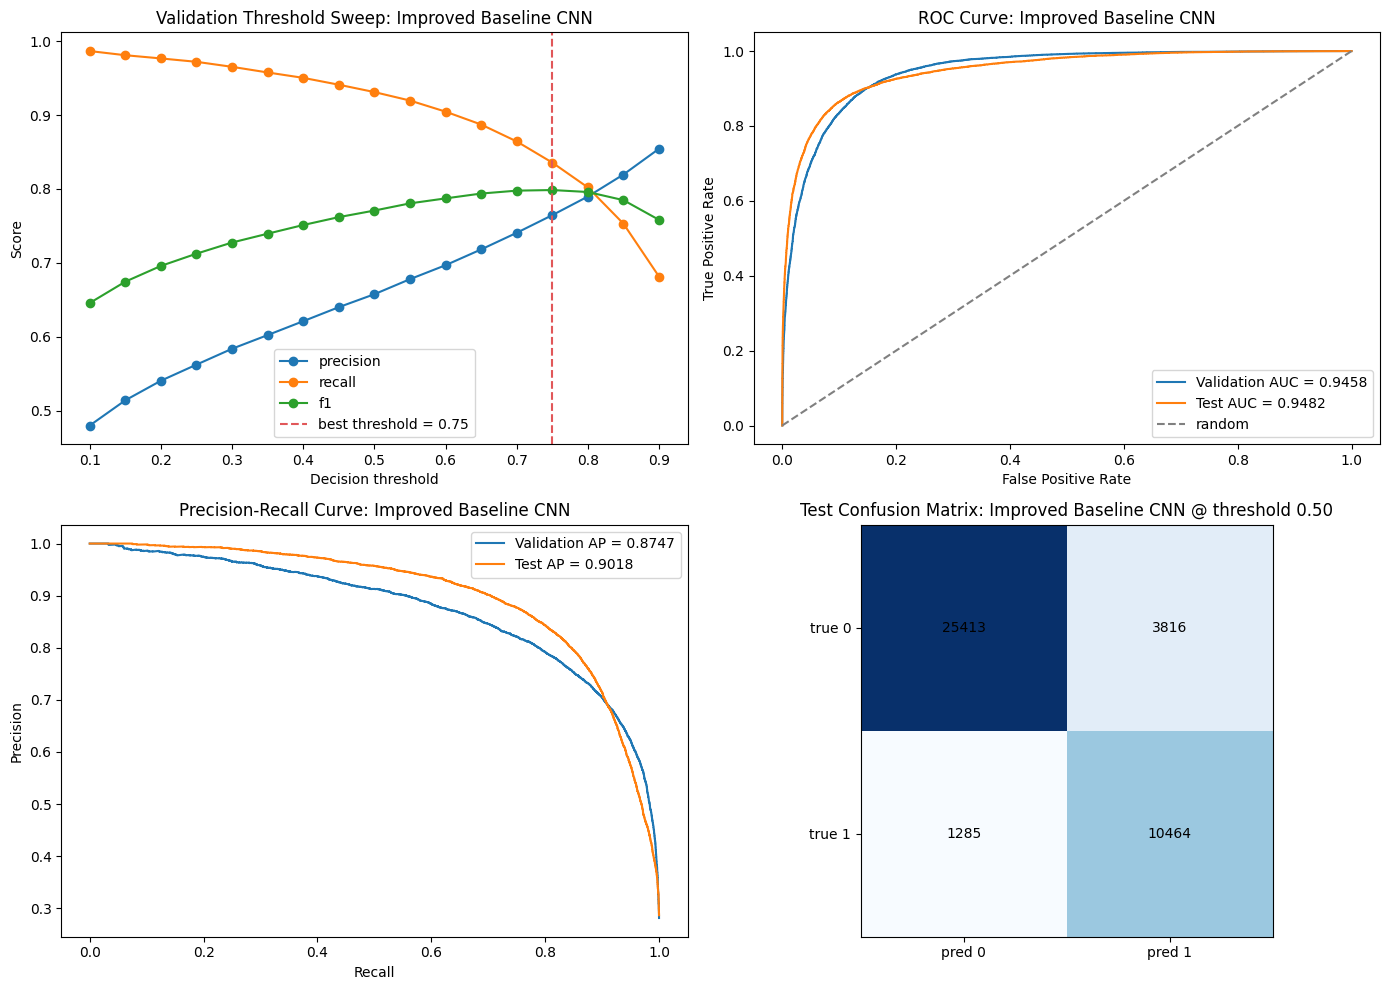

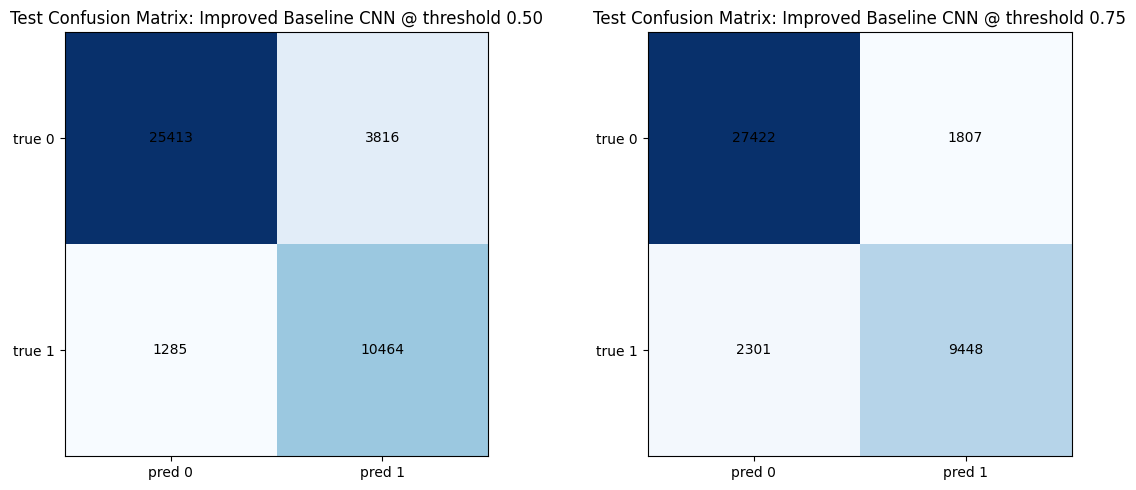

In [46]:
# Show the top validation thresholds before plotting the chosen operating point.
display(active_context['threshold_sweep_df'].sort_values(THRESHOLD_METRIC, ascending=False).head(10))
display(active_context['val_threshold_comparison_df'])
display(active_context['test_threshold_comparison_df'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(
    active_context['threshold_sweep_df']['threshold'],
    active_context['threshold_sweep_df']['precision'],
    marker='o',
    label='precision',
)
axes[0, 0].plot(
    active_context['threshold_sweep_df']['threshold'],
    active_context['threshold_sweep_df']['recall'],
    marker='o',
    label='recall',
)
axes[0, 0].plot(
    active_context['threshold_sweep_df']['threshold'],
    active_context['threshold_sweep_df']['f1'],
    marker='o',
    label='f1',
)
axes[0, 0].axvline(
    active_context['best_threshold'],
    color='#E15759',
    linestyle='--',
    label=f"best threshold = {active_context['best_threshold']:.2f}",
)
axes[0, 0].set_title(f"Validation Threshold Sweep: {active_context['model_display_name']}")
axes[0, 0].set_xlabel('Decision threshold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].legend()

axes[0, 1].plot(
    active_context['val_roc_curve_df']['fpr'],
    active_context['val_roc_curve_df']['tpr'],
    label=f"Validation AUC = {active_context['val_default_metrics'].roc_auc:.4f}",
)
axes[0, 1].plot(
    active_context['test_roc_curve_df']['fpr'],
    active_context['test_roc_curve_df']['tpr'],
    label=f"Test AUC = {active_context['test_default_metrics'].roc_auc:.4f}",
)
axes[0, 1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='random')
axes[0, 1].set_title(f"ROC Curve: {active_context['model_display_name']}")
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend()

axes[1, 0].plot(
    active_context['val_pr_curve_df']['recall'],
    active_context['val_pr_curve_df']['precision'],
    label=f"Validation AP = {active_context['val_average_precision']:.4f}",
)
axes[1, 0].plot(
    active_context['test_pr_curve_df']['recall'],
    active_context['test_pr_curve_df']['precision'],
    label=f"Test AP = {active_context['test_average_precision']:.4f}",
)
axes[1, 0].set_title(f"Precision-Recall Curve: {active_context['model_display_name']}")
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()

default_matrix = confusion_matrix_from_metrics(active_context['test_default_metrics'])
best_matrix = confusion_matrix_from_metrics(active_context['test_best_metrics'])
plot_confusion_matrix(axes[1, 1], default_matrix, f"Test Confusion Matrix: {active_context['model_display_name']} @ threshold 0.50")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_confusion_matrix(axes[0], default_matrix, f"Test Confusion Matrix: {active_context['model_display_name']} @ threshold 0.50")
plot_confusion_matrix(axes[1], confusion_matrix_from_metrics(active_context['test_best_metrics']), f"Test Confusion Matrix: {active_context['model_display_name']} @ threshold {active_context['best_threshold']:.2f}")
plt.tight_layout()
plt.show()


In [47]:
EVALUATION_DIR.mkdir(parents=True, exist_ok=True)

threshold_sweep_path = EVALUATION_DIR / 'val_threshold_sweep.csv'
val_roc_curve_path = EVALUATION_DIR / 'val_roc_curve.csv'
test_roc_curve_path = EVALUATION_DIR / 'test_roc_curve.csv'
val_pr_curve_path = EVALUATION_DIR / 'val_precision_recall_curve.csv'
test_pr_curve_path = EVALUATION_DIR / 'test_precision_recall_curve.csv'
summary_path = EVALUATION_DIR / 'evaluation_summary.json'

active_context['threshold_sweep_df'].to_csv(threshold_sweep_path, index=False)
active_context['val_roc_curve_df'].to_csv(val_roc_curve_path, index=False)
active_context['test_roc_curve_df'].to_csv(test_roc_curve_path, index=False)
active_context['val_pr_curve_df'].to_csv(val_pr_curve_path, index=False)
active_context['test_pr_curve_df'].to_csv(test_pr_curve_path, index=False)

evaluation_summary = {
    'run_name': active_context['run_name'],
    'checkpoint_epoch': active_context['checkpoint']['epoch'],
    'architecture': active_context['architecture'],
    'threshold_metric': THRESHOLD_METRIC,
    'default_threshold': active_context['default_threshold'],
    'selected_threshold': active_context['best_threshold'],
    'validation_average_precision': active_context['val_average_precision'],
    'test_average_precision': active_context['test_average_precision'],
    'test_metrics_threshold_0_50': active_context['test_default_metrics'].to_dict(),
    'tuned_test_metrics': active_context['test_best_metrics'].to_dict(),
    'training_run_metrics': load_json(active_context['run_dir'] / 'metrics.json'),
}

summary_path.write_text(json.dumps(evaluation_summary, indent=2) + '\n')

print(f'Saved threshold sweep: {threshold_sweep_path}')
print(f'Saved val ROC curve: {val_roc_curve_path}')
print(f'Saved test ROC curve: {test_roc_curve_path}')
print(f'Saved val PR curve: {val_pr_curve_path}')
print(f'Saved test PR curve: {test_pr_curve_path}')
print(f'Saved evaluation summary: {summary_path}')


Saved threshold sweep: /content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_improved_seed42/evaluation/val_threshold_sweep.csv
Saved val ROC curve: /content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_improved_seed42/evaluation/val_roc_curve.csv
Saved test ROC curve: /content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_improved_seed42/evaluation/test_roc_curve.csv
Saved val PR curve: /content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_improved_seed42/evaluation/val_precision_recall_curve.csv
Saved test PR curve: /content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_improved_seed42/evaluation/test_precision_recall_curve.csv
Saved evaluation summary: /content/drive/MyDrive/Workshop UDL/training_runs/baseline_cnn_improved_seed42/evaluation/evaluation_summary.json


Final comparison summary at fixed threshold = 0.50


,Model,Comparison Threshold,Best Tuned Threshold,Accuracy,Precision,Recall,F1,AP,ROC-AUC
0,Pretrained ResNet18,0.5,0.70,0.8828,0.7699,0.8434,0.8050,0.8881,0.9418
1,Improved Baseline CNN,0.5,0.75,0.8755,0.7328,0.8906,0.8040,0.9018,0.9482
2,Baseline CNN,0.5,0.60,0.8806,0.7689,0.8342,0.8002,0.8818,0.9356


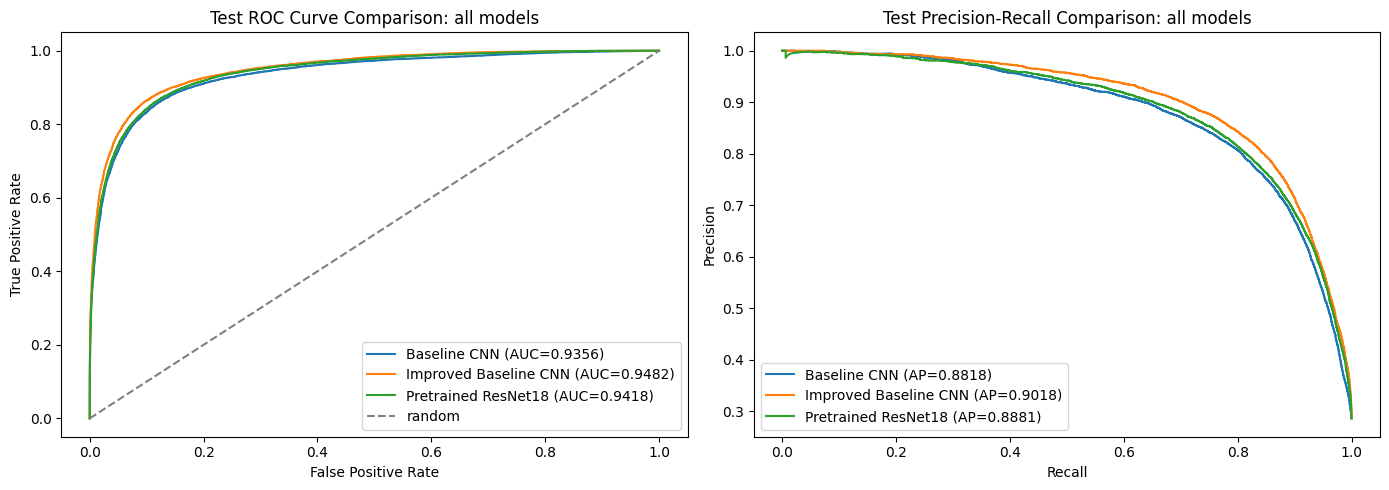

Saved comparison summary: /content/drive/MyDrive/Workshop UDL/model_comparison/model_comparison_summary.csv
Saved comparison table: /content/drive/MyDrive/Workshop UDL/model_comparison/model_comparison_table.csv


In [48]:
RUN_MODEL_COMPARISON = True
# A fixed comparison threshold makes threshold-dependent metrics directly comparable across models.
COMPARISON_THRESHOLD = 0.50
COMPARISON_RUNS = [
    ('Baseline CNN', 'baseline_cnn_seed42'),
    ('Improved Baseline CNN', 'baseline_cnn_improved_seed42'),
    ('Pretrained ResNet18', 'resnet18_transfer_seed42'),
]

comparison_contexts = []
comparison_rows = []

if RUN_MODEL_COMPARISON:
    for model_label, run_name in COMPARISON_RUNS:
        try:
            context = active_context if run_name == RUN_NAME else evaluate_saved_run(
                run_name,
                dataset_dir=dataset_dir,
                val_csv_path=val_csv_path,
                test_csv_path=test_csv_path,
                device=device,
                evaluation_batch_size=EVALUATION_BATCH_SIZE,
                evaluation_num_workers=EVALUATION_NUM_WORKERS,
                thresholds=THRESHOLDS,
                threshold_metric=THRESHOLD_METRIC,
            )
        except FileNotFoundError as exc:
            print(f'Skipping {run_name}: {exc}')
            continue

        fixed_threshold_metrics = compute_binary_metrics(
            context['test_outputs'].labels,
            context['test_outputs'].probabilities,
            threshold=COMPARISON_THRESHOLD,
        )

        comparison_contexts.append((model_label, context))
        comparison_rows.append(
            {
                'model_label': model_label,
                'run_name': run_name,
                'architecture': context['architecture'],
                'checkpoint_epoch': context['checkpoint']['epoch'],
                'comparison_threshold': COMPARISON_THRESHOLD,
                'selected_threshold': context['best_threshold'],
                'test_accuracy_default': context['test_default_metrics'].accuracy,
                'test_precision_default': context['test_default_metrics'].precision,
                'test_recall_default': context['test_default_metrics'].recall,
                'test_f1_default': context['test_default_metrics'].f1,
                'test_accuracy_fixed': fixed_threshold_metrics.accuracy,
                'test_precision_fixed': fixed_threshold_metrics.precision,
                'test_recall_fixed': fixed_threshold_metrics.recall,
                'test_f1_fixed': fixed_threshold_metrics.f1,
                'test_accuracy_tuned': context['test_best_metrics'].accuracy,
                'test_precision_tuned': context['test_best_metrics'].precision,
                'test_recall_tuned': context['test_best_metrics'].recall,
                'test_f1_tuned': context['test_best_metrics'].f1,
                'test_roc_auc': context['test_default_metrics'].roc_auc,
                'test_average_precision': context['test_average_precision'],
            }
        )

    if comparison_rows:
        comparison_df = pd.DataFrame(comparison_rows)
        comparison_df = comparison_df.sort_values(
            by=['test_f1_fixed', 'test_roc_auc'],
            ascending=[False, False],
        ).reset_index(drop=True)

        comparison_display_df = comparison_df[
            [
                'model_label',
                'comparison_threshold',
                'selected_threshold',
                'test_accuracy_fixed',
                'test_precision_fixed',
                'test_recall_fixed',
                'test_f1_fixed',
                'test_average_precision',
                'test_roc_auc',
            ]
        ].rename(
            columns={
                'model_label': 'Model',
                'comparison_threshold': 'Comparison Threshold',
                'selected_threshold': 'Best Tuned Threshold',
                'test_accuracy_fixed': 'Accuracy',
                'test_precision_fixed': 'Precision',
                'test_recall_fixed': 'Recall',
                'test_f1_fixed': 'F1',
                'test_average_precision': 'AP',
                'test_roc_auc': 'ROC-AUC',
            }
        )
        metric_columns = ['Comparison Threshold', 'Best Tuned Threshold', 'Accuracy', 'Precision', 'Recall', 'F1', 'AP', 'ROC-AUC']
        comparison_display_df[metric_columns] = comparison_display_df[metric_columns].round(4)

        print(f'Final comparison summary at fixed threshold = {COMPARISON_THRESHOLD:.2f}')
        display(comparison_display_df)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for model_label, context in comparison_contexts:
            axes[0].plot(
                context['test_roc_curve_df']['fpr'],
                context['test_roc_curve_df']['tpr'],
                label=f"{model_label} (AUC={context['test_default_metrics'].roc_auc:.4f})",
            )
            axes[1].plot(
                context['test_pr_curve_df']['recall'],
                context['test_pr_curve_df']['precision'],
                label=f"{model_label} (AP={context['test_average_precision']:.4f})",
            )

        axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='random')
        axes[0].set_title('Test ROC Curve Comparison: all models')
        axes[0].set_xlabel('False Positive Rate')
        axes[0].set_ylabel('True Positive Rate')
        axes[0].legend()

        axes[1].set_title('Test Precision-Recall Comparison: all models')
        axes[1].set_xlabel('Recall')
        axes[1].set_ylabel('Precision')
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        comparison_summary_path = COMPARISON_DIR / 'model_comparison_summary.csv'
        comparison_table_path = COMPARISON_DIR / 'model_comparison_table.csv'
        comparison_df.to_csv(comparison_summary_path, index=False)
        comparison_display_df.to_csv(comparison_table_path, index=False)
        print(f'Saved comparison summary: {comparison_summary_path}')
        print(f'Saved comparison table: {comparison_table_path}')
    else:
        print('No comparison runs were available.')
else:
    print('Model comparison is disabled.')
